In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("house_price.csv")
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [3]:
# shape
df.shape

(13200, 7)

In [4]:
# columns
df.columns

Index(['location', 'size', 'total_sqft', 'bath', 'price', 'bhk',
       'price_per_sqft'],
      dtype='object')

In [5]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   bhk             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 722.0+ KB


In [6]:
# summary statistics
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.000000,13200.000000,13200.000000,13200.000000,1.320000e+04
mean,1555.302783,2.691136,112.276178,2.800833,7.920337e+03
std,1237.323445,1.338915,149.175995,1.292843,1.067272e+05
min,1.000000,1.000000,8.000000,1.000000,2.670000e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.267000e+03
50%,1275.000000,2.000000,71.850000,3.000000,5.438000e+03
75%,1672.000000,3.000000,120.000000,3.000000,7.317000e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [7]:
# missing values
df.isnull().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

## Price per sqft column check

In [8]:
df['price_per_sqft'].describe()

count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

## Outlier Removal

In [9]:
mean = df['price_per_sqft'].mean()
std = df['price_per_sqft'].std()

lower = mean - 3*std
upper = mean + 3*std

df_std = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]
df_std.shape

(13195, 7)

## Percentile Method (5% - 95%)

In [10]:
lower = df['price_per_sqft'].quantile(0.05)
upper = df['price_per_sqft'].quantile(0.95)

df_percentile = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]
df_percentile.shape

(11880, 7)

## IQR Method

In [11]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_iqr = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]
df_iqr.shape

(11935, 7)

## Z-Score Method

In [12]:
from scipy import stats

z = np.abs(stats.zscore(df['price_per_sqft']))

df_z = df[z < 3]
df_z.shape

(13195, 7)

## Box Plot (Before & After)

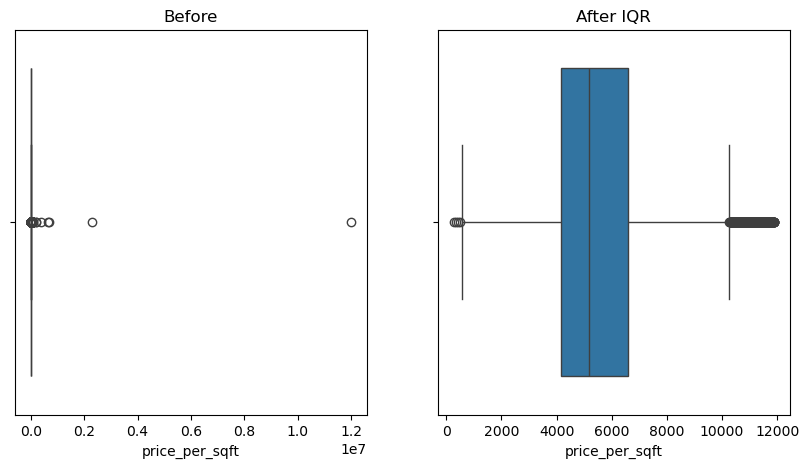

In [13]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['price_per_sqft'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(x=df_iqr['price_per_sqft'])
plt.title("After IQR")

plt.show()

## Histogram + Normality

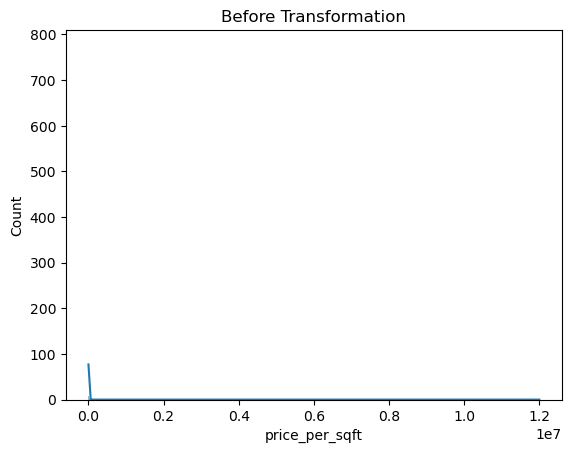

In [14]:
sns.histplot(df['price_per_sqft'], kde=True)
plt.title("Before Transformation")
plt.show()

In [15]:
df['price_per_sqft'].skew()

np.float64(108.28105529705168)

In [16]:
df['price_per_sqft'].kurt()

np.float64(12095.21502832288)

## Log Transformation

In [17]:
df['log_price'] = np.log(df['price_per_sqft'])

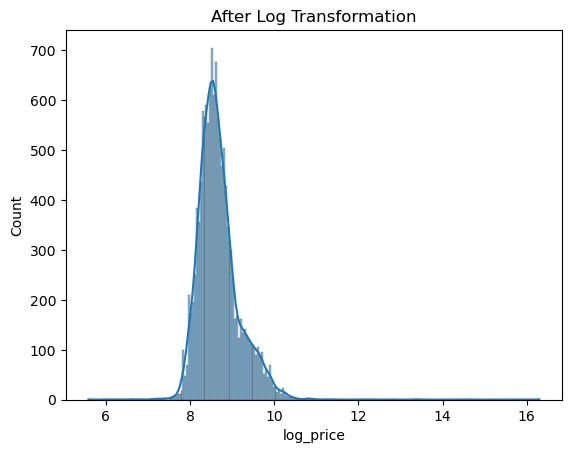

In [18]:
sns.histplot(df['log_price'], kde=True)
plt.title("After Log Transformation")
plt.show()

In [19]:
df['log_price'].skew()

np.float64(1.3998626551353)

In [20]:
df['log_price'].kurt()

np.float64(9.203576429862675)

## Correlation + Heatmap

In [22]:
corr = df.corr(numeric_only=True)

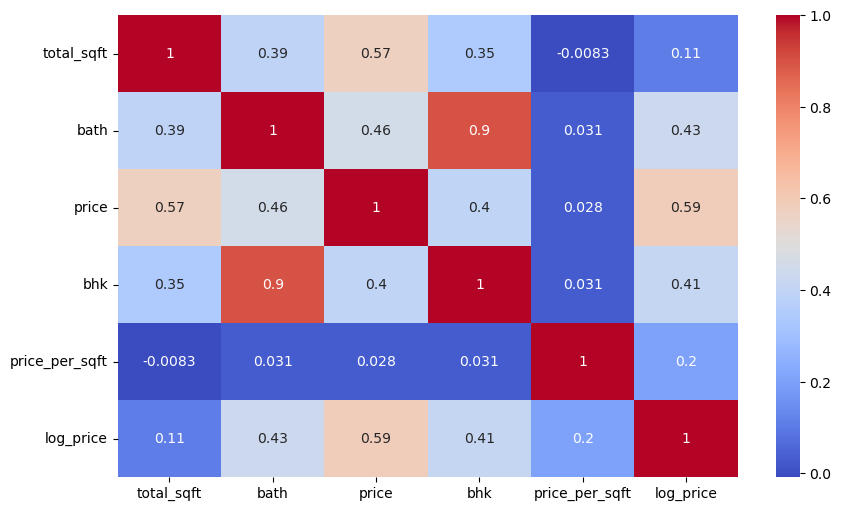

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Scatter Plot

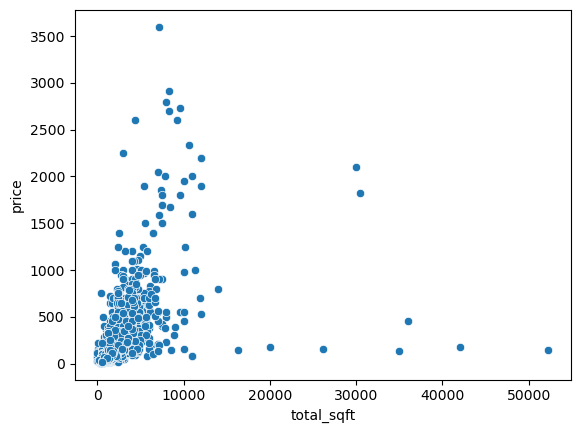

In [24]:
sns.scatterplot(x=df['total_sqft'], y=df['price'])
plt.show()